In [16]:
import scanpy as sc
import pandas as pd
import numpy as np
import logging
import os
from pathlib import Path
import anndata2ri
from bokeh.models import TabPanel, Tabs, ColorBar
from bokeh.plotting import show, output_file
from scipy.stats import median_abs_deviation
import seaborn as sns
import scrublet as scr
import seaborn as sns
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
from utils import interactive_embedding, gridlayout
import anndata as ad
from scipy.sparse import csr_matrix, issparse
from bokeh.plotting import show, output_file, output_notebook
from bokeh.layouts import row, grid
import warnings
import numpy as np
import scib

warnings.filterwarnings("ignore")
anndata2ri.activate()
%load_ext rpy2.ipython

# rcb.logger.setLevel(logging.ERROR)

sc.settings.verbosity = 0
sc.settings.set_figure_params(dpi=80, facecolor="white", frameon=False, figsize=(8, 5))

pd.set_option("display.max_columns", None)
sc.settings.verbosity = 1
output_notebook()
%matplotlib inline

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


Loading BokehJS ...

In [17]:
np.random.seed(42)

In [18]:
sample_path = Path("../../LBP_brain_blood_pairs/data/narsad_cellRanger_outs/blood/")

sample_list = []

sum_cells = 0
all_genes = []
for i, sample in enumerate(sorted(os.listdir(sample_path))):
    if os.path.splitext(sample)[1] == ".h5ad":
        adata_sample = sc.read(sample_path / sample)
        adata_sample.obs["pt"] = "-".join(sample.split("-")[:2])
        # adata_sample.obs['side'] = sample.split('-')[3].split("_")[0]
        all_genes.extend(list(adata_sample.var.index))
        print(i, sample, adata_sample.shape)
        sample_list.append(adata_sample)
        sum_cells += adata_sample.shape[0]

2 PT-182-blood-R_QC.h5ad (4308, 15740)
4 PT-185-blood-L_QC.h5ad (7853, 16034)
6 PT-201-blood-L_QC.h5ad (3051, 17008)
8 PT-203-blood-L_QC.h5ad (2120, 17347)
10 PT-203-blood-R_QC.h5ad (4398, 19243)
12 PT-205-blood-L_QC.h5ad (2703, 18080)
14 PT-205-blood-R_QC.h5ad (3294, 17638)
16 PT-206-blood-L_QC.h5ad (1041, 15638)
18 PT-208-blood-L_QC.h5ad (2057, 16270)
20 PT-208-blood-R_QC.h5ad (2108, 15950)
22 PT-212-blood-L_QC.h5ad (982, 15940)
24 PT-212-blood-R_QC.h5ad (3105, 15868)
26 PT-214-blood-L_QC.h5ad (5130, 17285)
28 PT-214-blood-R_QC.h5ad (3441, 17657)


In [19]:
sum_cells, len(all_genes), len(pd.unique(all_genes))

(45591, 235698, 21896)

In [20]:
adata_merged = ad.concat(sample_list, join="outer", index_unique="_")
adata_merged.obs_names_make_unique()
print(adata_merged.X[0, :6])
adata_merged.X = adata_merged.layers["counts"]
print(adata_merged.X[0, :6])

  (0, 0)	0.25320008
  (0, 5)	0.1345925
  (0, 3)	0.1345925
  (0, 0)	2.0
  (0, 5)	1.0
  (0, 3)	1.0


In [21]:
adata_merged.obs["chemistry"] = adata_merged.obs["pt"].apply(
    lambda x: "v2" if x in ["PT-182", "PT-185"] else "v3"
)

In [22]:
adata_merged.obs.head()

,n_genes_x,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_20_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,outlier,scDblFinder_score,scDblFinder_class,doublet_scores_scrublet,predicted_doublets_scrublet,cluster_labels,n_counts_lower_co,n_counts_upper_co,n_counts,n_counts_passed_qc,n_genes_lower_co,n_genes_upper_co,n_genes_y,n_genes_passed_qc,percent_mito_lower_co,percent_mito_upper_co,percent_mito,percent_mito_passed_qc,percent_ribo_lower_co,percent_ribo_upper_co,percent_ribo,percent_ribo_passed_qc,passed_qc,side,pt,chemistry
GATTCAGGTCCAACTA_0,3698,3697,8.215547,15718.0,9.662625,18.373839,653.0,6.483108,4.154472,4086.0,8.315566,25.995674,0.0,0.000000,0.000000,True,0.014536,1,0.131098,False,12,4246.0910,NaN,16073.0,True,200.0,NaN,3703.0,True,NaN,10.0,4.062714,True,NaN,35.484185,25.421514,True,True,R,PT-182,v2
CTCTACGTCAGGTAAA_0,2950,2949,7.989560,15273.0,9.633907,25.063838,343.0,5.840641,2.245793,4988.0,8.514991,32.658939,0.0,0.000000,0.000000,True,0.002240,1,0.043537,False,12,4246.0910,NaN,15548.0,True,200.0,NaN,2957.0,True,NaN,10.0,2.206072,True,NaN,35.484185,32.081297,True,True,R,PT-182,v2
GTGGGTCTCCAGATCA_0,3373,3372,8.123558,14625.0,9.590556,20.205128,500.0,6.216606,3.418804,3281.0,8.096209,22.434189,0.0,0.000000,0.000000,True,0.004022,1,0.051437,False,12,4246.0910,NaN,14811.0,True,200.0,NaN,3379.0,True,NaN,10.0,3.375869,True,NaN,35.484185,22.152454,True,True,R,PT-182,v2
TTGTAGGAGCCCGAAA_0,3153,3152,8.056110,13792.0,9.531917,18.445476,343.0,5.840641,2.486949,4530.0,8.418698,32.845127,1.0,0.693147,0.007251,True,0.002672,1,0.053696,False,12,4246.0910,NaN,14045.0,True,200.0,NaN,3155.0,True,NaN,10.0,2.442150,True,NaN,35.484185,32.253471,True,True,R,PT-182,v2
GACGTTATCTGTTGAG_0,3071,3070,8.029759,13094.0,9.479986,19.107988,567.0,6.342122,4.330227,4039.0,8.304000,30.846191,0.0,0.000000,0.000000,True,0.999721,2,0.211982,False,7,632.0532,NaN,13384.0,True,200.0,NaN,3076.0,True,NaN,10.0,4.236402,True,NaN,30.478072,30.177824,True,True,R,PT-182,v2


In [23]:
scales_counts = sc.pp.normalize_total(
    adata_merged,
    layer="counts",
    exclude_highly_expressed=True,
    target_sum=None,
    inplace=False,
)
# log1p transform
adata_merged.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)

In [24]:
adata_merged.obs["scrublet_class_refined"] = adata_merged.obs[
    "doublet_scores_scrublet"
].apply(lambda x: "singlet" if x < 0.2 else "doublet")

In [25]:
sc.tl.pca(adata_merged, svd_solver="arpack", n_comps=25, use_highly_variable=False)
print(np.sum(adata_merged.uns["pca"]["variance_ratio"]))

0.96583706


In [26]:
labels = [
    "chemistry",
    "pt",
    "side",
    "total_counts",
    "n_genes_by_counts",
    "pct_counts_mt",
    "pct_counts_ribo",
    "scDblFinder_score",
    "scDblFinder_class",
    "doublet_scores_scrublet",
    "predicted_doublets_scrublet",
    "scrublet_class_refined",
    "passed_qc",
]

In [29]:
# sc.pp.normalize_total(adata_merged)
# sc.pp.log1p(adata_merged)
adata_log1p = adata_merged.copy()
adata_log1p.X = adata_log1p.layers["log1p_norm"]
sc.pp.pca(adata_log1p, svd_solver="arpack", n_comps=25)
sc.pp.neighbors(adata_log1p)
sc.tl.umap(adata_log1p)
# sc.pl.umap(adata_log1p, color=labels, show=False)

In [ ]:
sc.pl.umap(adata_log1p, color=labels, show=False, return_fig=False)

In [ ]:
gridlayout(
    labels,
    adata_log1p,
    f"../LBP_brain_blood_pairs/PLOTS/QC_plots/merged_blood_cellbender_QC.html",
)

In [ ]:
# labels = ['chemistry','pt',"side","log1p_total_counts",'pct_counts_in_top_20_genes',"pct_counts_mt", "pct_counts_ribo", "pct_counts_hb", "scDblFinder_score", "doublet_scores_scrublet", "scDblFinder_class", "predicted_doublets_scrublet",'scrublet_class_refined', "passed_qc"]

# tabs = []

# for label in labels:
#     print(label)
#     tabs.append(TabPanel(child=interactive_embedding(adata_log1p, label), title=label))

# p = Tabs(tabs=tabs)
# output_file(f"../LBP_brain_blood_pairs/PLOTS/QC_plots/merged_blood_cellbender_QC.html")

# #
# show(p)

## Filter data

In [27]:
adata_filtered = adata_merged[
    (adata_merged.obs["scrublet_class_refined"] == "singlet")
    & (adata_merged.obs["passed_qc"] == "True")
    & (adata_merged.obs["pct_counts_mt"] < 40)
].copy()

In [28]:
print(adata_merged, adata_filtered)

AnnData object with n_obs × n_vars = 45591 × 21896
    obs: 'n_genes_x', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'scDblFinder_score', 'scDblFinder_class', 'doublet_scores_scrublet', 'predicted_doublets_scrublet', 'cluster_labels', 'n_counts_lower_co', 'n_counts_upper_co', 'n_counts', 'n_counts_passed_qc', 'n_genes_lower_co', 'n_genes_upper_co', 'n_genes_y', 'n_genes_passed_qc', 'percent_mito_lower_co', 'percent_mito_upper_co', 'percent_mito', 'percent_mito_passed_qc', 'percent_ribo_lower_co', 'percent_ribo_upper_co', 'percent_ribo', 'percent_ribo_passed_qc', 'passed_qc', 'side', 'pt', 'chemistry', 'scrublet_class_refined'
    uns: 'pca'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'log1p_norm' 

In [30]:
adata_filtered.X = adata_filtered.layers["counts"].copy()
scales_counts = sc.pp.normalize_total(
    adata_filtered,
    layer="counts",
    exclude_highly_expressed=True,
    target_sum=None,
    inplace=False,
)
# log1p transform
adata_filtered.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)
adata_filtered.X = adata_filtered.layers["log1p_norm"].copy()

0.25734544


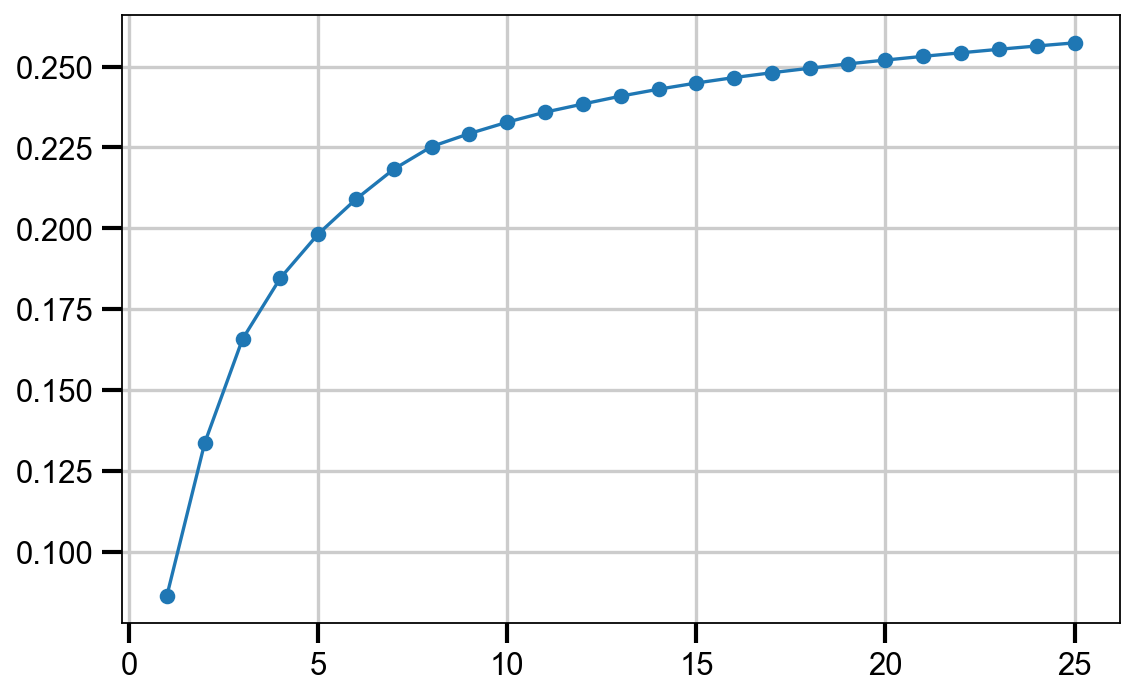

In [31]:
import matplotlib.pyplot as plt

sc.pp.pca(adata_filtered, svd_solver="arpack", n_comps=25)
cumulative_explained_variance = np.cumsum(adata_filtered.uns["pca"]["variance_ratio"])
print(np.sum(adata_filtered.uns["pca"]["variance_ratio"]))
plt.plot(
    range(1, len(cumulative_explained_variance) + 1),
    cumulative_explained_variance,
    marker="o",
)

In [32]:
labels = [
    "chemistry",
    "pt",
    "side",
    "log1p_total_counts",
    "n_genes_by_counts",
    "pct_counts_mt",
    "pct_counts_ribo",
]

In [ ]:
sc.pp.pca(adata_filtered, svd_solver="arpack", n_comps=25)

sc.pp.neighbors(adata_filtered)
sc.tl.umap(adata_filtered)
sc.pl.umap(adata_filtered, color=labels)

gridlayout(
    labels,
    adata_filtered,
    f"../LBP_brain_blood_pairs/PLOTS/QC_plots/merged_blood_cellbender_QC_filtered.html",
)

In [13]:
%%R
library(scran)
library(BiocParallel)

R[write to console]: Loading required package: SingleCellExperiment

R[write to console]: Loading required package: SummarizedExperiment

R[write to console]: Loading required package: MatrixGenerics

R[write to console]: Loading required package: matrixStats

R[write to console]: 
Attaching package: ‘MatrixGenerics’


R[write to console]: The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowC

In [14]:
# Preliminary clustering for differentiated normalisation
adata_filtered.X = adata_filtered.layers["counts"].copy()

adata_pp = adata_filtered.copy()
sc.pp.normalize_total(adata_pp)  ## already normalized
sc.pp.log1p(adata_pp)
sc.pp.pca(adata_pp, n_comps=25)
sc.pp.neighbors(adata_pp)
sc.tl.leiden(adata_pp, key_added="groups")

data_mat = adata_pp.X.T
# convert to CSC if possible. See https://github.com/MarioniLab/scran/issues/70
if issparse(data_mat):
    if data_mat.nnz > 2**31 - 1:
        data_mat = data_mat.tocoo()

    else:
        data_mat = data_mat.tocsc()
ro.globalenv["data_mat"] = data_mat
ro.globalenv["input_groups"] = adata_pp.obs["groups"]

del adata_pp

In [15]:
%%R -o size_factors

size_factors = sizeFactors(
    computeSumFactors(
        SingleCellExperiment(
            list(counts=data_mat)), 
            clusters = input_groups,
            min.mean = 0.1,
            BPPARAM = MulticoreParam()
    )
)

In [ ]:
adata_filtered.obs["size_factors"] = size_factors
scran = adata_filtered.X / adata_filtered.obs["size_factors"].values[:, None]
adata_filtered.layers["scran_normalization"] = csr_matrix(sc.pp.log1p(scran))

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(adata_filtered.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(
    adata_filtered.layers["scran_normalization"].sum(1), bins=100, kde=False, ax=axes[1]
)
axes[1].set_title("log1p with Scran estimated size factors")
plt.show()

In [ ]:
adata_filtered

In [ ]:
print(adata_filtered.layers["counts"][0, 9:12])

In [ ]:
adata_scran = adata_filtered.copy()

adata_scran.X = adata_scran.layers["scran_normalization"]
sc.pp.pca(adata_scran, svd_solver="arpack", n_comps=25)
sc.pp.neighbors(adata_scran)
sc.tl.umap(adata_scran)
sc.pl.umap(adata_scran, color=labels)
tabs = []

for label in labels:
    tabs.append(TabPanel(child=interactive_embedding(adata_scran, label), title=label))

p = Tabs(tabs=tabs)
# output_file(f"../LBP_brain_blood_pairs/PLOTS/QC_plots/{PT}-blood-{side}_cellbender_QC.html")

#
show(p)

In [33]:
adata_filtered.X = adata_filtered.layers["counts"].copy()

analytic_pearson = sc.experimental.pp.normalize_pearson_residuals(
    adata_filtered, inplace=False
)
adata_filtered.layers["analytic_pearson_residuals"] = csr_matrix(analytic_pearson["X"])

In [ ]:
adata_scran = adata_filtered.copy()

adata_scran.X = adata_scran.layers["analytic_pearson_residuals"]
sc.pp.pca(adata_scran, svd_solver="arpack", n_comps=25)
sc.pp.neighbors(adata_scran)
sc.tl.umap(adata_scran)
sc.pl.umap(adata_scran, color=labels)
tabs = []

for label in labels:
    tabs.append(TabPanel(child=interactive_embedding(adata_scran, label), title=label))

p = Tabs(tabs=tabs)
# output_file(f"../LBP_brain_blood_pairs/PLOTS/QC_plots/{PT}-blood-{side}_cellbender_QC.html")

#
show(p)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(adata_filtered.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(
    np.nansum(analytic_pearson["X"], axis=1), bins=100, kde=False, ax=axes[1]
)
axes[1].set_title("Analytic Pearson residuals")

plt.show()

In [ ]:
print(adata_filtered.X[0, :6])
print("====")
print(adata_filtered.layers["counts"][0, :6])
print("====")
print(adata_filtered.layers["log1p_norm"][0, :6])
print("====")
print(adata_filtered.layers["scran_normalization"][0, :6])
print("====")
print(adata_filtered.layers["analytic_pearson_residuals"][0, :6])

In [ ]:
# Remove doublets
# adata_b1 = adata_b1[adata_b1.obs['predicted_doublets_scrublet'] == False,:]
# adata_b1[adata_b1.obs['predicted_doublets_scrublet'] & adata_b1[adata_b1.obs['predicted_doublets_scrublet']
# print(len(set(adata_b1.obs[adata_b1.obs["scDblFinder_class"]=='singlet'].index).intersection(adata_b1.obs[adata_b1.obs['predicted_doublets_scrublet']==False].index)))
# print(len(set(adata_b1.obs[adata_b1.obs["scDblFinder_class"]=='singlet'].index)), len(set(adata_b1.obs[adata_b1.obs["predicted_doublets_scrublet"]==False].index)) )
# adata_b1 = adata_b1[(adata_b1.obs["scDblFinder_class"]=='singlet') & (adata_b1.obs['predicted_doublets_scrublet']==False)]
# adata_b1

### Feature selection

In [ ]:
mito_genes = adata_filtered.var_names.str.startswith("MT-")
keep = np.invert(mito_genes)

# adata_b1 = adata_b1[:,keep]
# adata_b
mito_genes.sum()

In [ ]:
# sc.pp.highly_variable_genes(
#     adata_filtered, layer='counts', n_top_genes=3000, flavor="seurat_v3", batch_key='pt'
# ) # expect counts

sc.experimental.pp.highly_variable_genes(
    adata_filtered,
    layer="counts",
    flavor="pearson_residuals",
    n_top_genes=3000,
    batch_key="chemistry",
)

# sc.pp.highly_variable_genes(
#     adata_scran, layer='scran_normalization',  n_top_genes=3000,  batch_key='chemistry'
# ) # expect log data

In [ ]:
# n_batches = adata_b1.var["highly_variable_nbatches"].value_counts()
# ax = n_batches.plot(kind="bar")
# n_batches

In [ ]:
adata_filtered.X = adata_filtered.layers["log1p_norm"]
sc.pp.pca(adata_filtered, svd_solver="arpack", n_comps=25, use_highly_variable=True)

sc.pp.neighbors(adata_filtered, n_neighbors=20)
sc.tl.umap(adata_filtered)

In [ ]:
gridlayout(
    labels,
    adata_filtered,
    f"../LBP_brain_blood_pairs/PLOTS/QC_plots/merged_blood_cellbender_QC_filtered.html",
)

In [ ]:
sc.pl.umap(adata_filtered, color=labels)

tabs = []

for label in labels:
    tabs.append(
        TabPanel(child=interactive_embedding(adata_filtered, label), title=label)
    )

p = Tabs(tabs=tabs)
# output_file(f"../LBP_brain_blood_pairs/PLOTS/QC_plots/{PT}-blood-{side}_cellbender_QC.html")

#
show(p)

In [ ]:
adata_filtered.X = adata_filtered.layers["counts"].copy()

# ro.globalenv["adata_filtered"] = adata_filtered

In [ ]:
adata_filtered.obs

In [ ]:
%%R -i adata_filtered -o sce
library(scry)
colData(adata_filtered)$pt <- as.factor(colData(adata_filtered)$pt)
sce = devianceFeatureSelection(adata_filtered, assay="X") #, batch=colData(adata_filtered)$pt)

In [ ]:
binomial_deviance = ro.r("rowData(sce)$binomial_deviance").T
idx = binomial_deviance.argsort()[-4000:]
mask = np.zeros(adata_filtered.var_names.shape, dtype=bool)
mask[idx] = True

adata_filtered.var["highly_deviant"] = mask
adata_filtered.var["binomial_deviance"] = binomial_deviance

In [ ]:
adata_filtered.var["highly_variable"] = adata_filtered.var["highly_deviant"]

In [ ]:
adata_filtered.var["highly_variable"].sum()

In [ ]:
sorted(
    list(
        adata_filtered.var["highly_deviant"][
            np.where(adata_filtered.var["highly_deviant"])[0]
        ].index
    )
)

In [ ]:
adata_filtered.X = adata_filtered.layers["log1p_norm"].copy()
sc.pp.pca(adata_filtered, svd_solver="arpack", n_comps=25, use_highly_variable=True)

sc.pp.neighbors(adata_filtered)
sc.tl.umap(adata_filtered)
sc.pl.umap(adata_filtered, color=["chemistry", "pt", "side"])

In [ ]:
labels = [
    "chemistry",
    "pt",
    "side",
    "log1p_total_counts",
    "n_genes_by_counts",
    "pct_counts_mt",
    "pct_counts_ribo",
    "scDblFinder_score",
    "scDblFinder_class",
    "doublet_scores_scrublet",
    "predicted_doublets_scrublet",
    "scrublet_class_refined",
    "passed_qc",
]

sc.pl.umap(adata_filtered, color=labels)

In [ ]:
sc.pp.highly_variable_genes(adata_filtered, layer="scran_normalization")

ax = sns.scatterplot(
    data=adata_filtered.var, x="means", y="dispersions", hue="highly_deviant", s=5
)
ax.set_xlim(None, 1.5)
ax.set_ylim(None, 3)

## Data integration

In [ ]:
np.random.seed(42)

In [ ]:
adata_filtered.X = adata_filtered.layers["counts"]
sc.pp.filter_genes(adata_filtered, min_cells=1)

In [ ]:
sc.experimental.pp.highly_variable_genes(
    adata_filtered,
    layer="counts",
    flavor="pearson_residuals",
    n_top_genes=4000,
    batch_key="chemistry",
)

In [ ]:
n_batches = adata_filtered.var["highly_variable_nbatches"].value_counts()
ax = n_batches.plot(kind="bar")
n_batches

In [ ]:
sc.pp.highly_variable_genes(
    adata_filtered, n_top_genes=4000, flavor="cell_ranger", batch_key="chemistry"
)

In [ ]:
adata_filtered.var["highly_variable"] = adata_filtered.var["highly_deviant"]

In [ ]:
adata_hvg = adata_filtered[:, adata_filtered.var["highly_variable"]].copy()
adata_hvg.X = adata_hvg.layers["counts"].copy()

In [ ]:
adata_hvg.layers["counts"][0, 9]

In [ ]:
## REMOVE MT GENES???

In [ ]:
# sc.pp.highly_variable_genes(
#     adata_scran, layer='counts', n_top_genes=3000, flavor="seurat_v3", batch_key='side'
# )
# adata_hvg = adata_scran[:, adata_scran.var["highly_variable"]].copy()
sc.pp.normalize_total(adata_hvg)
sc.pp.log1p(adata_hvg)
sc.pp.pca(adata_hvg, svd_solver="arpack")
adata_hvg.layers["logcounts"] = adata_hvg.X.copy()

sc.pp.neighbors(adata_hvg)
sc.tl.umap(adata_hvg)

In [ ]:
sc.pl.umap(adata_hvg, color=labels)

In [ ]:
gridlayout(
    labels,
    adata_hvg,
    f"../../LBP_brain_blood_pairs/PLOTS/QC_plots/merged_blood_cellbender_QC_filtered_4000highlyDeviant.html",
)

In [ ]:
import scanpy.external as sce

labels = [
    "chemistry",
    "pt",
    "side",
    "log1p_total_counts",
    "n_genes_by_counts",
    "pct_counts_mt",
    "pct_counts_ribo",
]

adata_harmony = adata_hvg.copy()
# sc.pp.pca(adata_harmony, svd_solver="arpack", use_highly_variable=False)

sce.pp.harmony_integrate(
    adata_harmony, key="chemistry", adjusted_basis="X_pca_harmony_chem"
)
sc.pp.neighbors(adata_harmony, use_rep="X_pca_harmony_chem")
sc.tl.umap(adata_harmony)
# sc.pl.umap(adata_harmony, color=labels, wspace=1)

In [ ]:
print(adata_harmony.layers["counts"][0, 9], adata_hvg.layers["counts"][0, 9])

In [ ]:
sc.pl.umap(adata_harmony, color=labels, wspace=1)

In [ ]:
gridlayout(
    labels,
    adata_harmony,
    f"../../LBP_brain_blood_pairs/PLOTS/QC_plots/merged_blood_cellbender_QC_filtered_4000highlyDeviant_harmonyChem.html",
)

In [ ]:
sce.pp.harmony_integrate(
    adata_harmony,
    "pt",
    basis="X_pca_harmony_chem",
    adjusted_basis="X_pca_harmony_chempt",
)
sc.pp.neighbors(adata_harmony, use_rep="X_pca_harmony_chempt")
sc.tl.umap(adata_harmony)

In [ ]:
print(adata_harmony.layers["counts"][0, 9], adata_hvg.layers["counts"][0, 9])

In [ ]:
gridlayout(
    labels,
    adata_harmony,
    f"../../LBP_brain_blood_pairs/PLOTS/QC_plots/merged_blood_cellbender_QC_filtered_4000highlyDeviant_harmonyChemPt.html",
)

In [ ]:
sce.pp.harmony_integrate(
    adata_harmony,
    "side",
    basis="X_pca_harmony_chempt",
    adjusted_basis="X_pca_harmony_chemptside",
)
sc.pp.neighbors(adata_harmony, use_rep="X_pca_harmony_chemptside")
sc.tl.umap(adata_harmony)
# sc.pl.umap(adata_harmony, color=labels, wspace=1)

In [ ]:
print(adata_harmony.layers["counts"][0, 9], adata_hvg.layers["counts"][0, 9])

In [ ]:
sc.pl.umap(adata_harmony, color=labels, wspace=1)

In [ ]:
gridlayout(
    labels,
    adata_harmony,
    f"../../LBP_brain_blood_pairs/PLOTS/QC_plots/merged_blood_cellbender_QC_filtered_4000highlyDeviant_harmonyChemPtSide.html",
)

In [ ]:
import scib

# PCR_score: the higher the better, range 0-1
print(
    "Unintegrated:",
    scib.metrics.pcr_comparison(adata_filtered, adata_hvg, covariate="side"),
    "\n",
)

print(
    "Harmony chemistry",
    scib.metrics.pcr_comparison(
        adata_hvg,
        adata_harmony,
        covariate="chemistry",
        embed="X_pca_harmony_chemptside",
    ),
    "\n",
)
print(
    "Harmony pt",
    scib.metrics.pcr_comparison(
        adata_hvg, adata_harmony, covariate="pt", embed="X_pca_harmony_chemptside"
    ),
    "\n",
)
print(
    "Harmony side",
    scib.metrics.pcr_comparison(
        adata_hvg, adata_harmony, covariate="side", embed="X_pca_harmony_chemptside"
    ),
)

In [ ]:
import scvi

adata_scvi = adata_hvg.copy()

scvi.model.SCVI.setup_anndata(
    adata_scvi,
    layer="counts",
    batch_key="pt",
    categorical_covariate_keys=["chemistry", "side"],
)
model_scvi = scvi.model.SCVI(adata_scvi)

In [ ]:
# model_scvi.view_anndata_setup()
# max_epochs_scvi = np.min([round((20000 / adata_scvi.n_obs) * 400), 400])

In [ ]:
model_scvi.train(use_gpu=False)
adata_scvi.obsm["X_scVI"] = model_scvi.get_latent_representation()
adata_scvi.layers["X_normalized_scVI"] = model_scvi.get_normalized_expression()

In [ ]:
print(adata_scvi.layers["counts"][0, 9], adata_hvg.layers["counts"][0, 9])

In [ ]:
sc.pp.neighbors(adata_scvi, use_rep="X_scVI")
sc.tl.umap(adata_scvi)

In [ ]:
sc.pl.umap(adata_scvi, color=labels, wspace=1)

In [ ]:
# sc.pl.umap(adata_scvi, color=labels, wspace=1)
gridlayout(
    labels,
    adata_scvi,
    f"../../LBP_brain_blood_pairs/PLOTS/QC_plots/merged_blood_cellbender_QC_filtered_4000highlyDeviant_scvi.html",
)

## Compare methods

In [ ]:
adata_filtered

In [ ]:
unintegrated_metrics_pcr = [
    scib.metrics.pcr_comparison(adata_filtered, adata_hvg, covariate="chemistry"),
    scib.metrics.pcr_comparison(adata_filtered, adata_hvg, covariate="pt"),
    scib.metrics.pcr_comparison(adata_filtered, adata_hvg, covariate="side"),
]
harmony_metrics_pcr = [
    scib.metrics.pcr_comparison(
        adata_hvg,
        adata_harmony,
        covariate="chemistry",
        embed="X_pca_harmony_chemptside",
    ),
    scib.metrics.pcr_comparison(
        adata_hvg, adata_harmony, covariate="pt", embed="X_pca_harmony_chemptside"
    ),
    scib.metrics.pcr_comparison(
        adata_hvg, adata_harmony, covariate="side", embed="X_pca_harmony_chemptside"
    ),
]
scvi_metrics_pcr = [
    scib.metrics.pcr_comparison(
        adata_hvg, adata_scvi, covariate="chemistry", embed="X_scVI"
    ),
    scib.metrics.pcr_comparison(adata_hvg, adata_scvi, covariate="pt", embed="X_scVI"),
    scib.metrics.pcr_comparison(
        adata_hvg, adata_scvi, covariate="side", embed="X_scVI"
    ),
]

unintegrated_metrics_cellc = [
    scib.me.cell_cycle(
        adata_filtered, adata_hvg, batch_key="chemistry", organism="human"
    ),
    scib.me.cell_cycle(adata_filtered, adata_hvg, batch_key="pt", organism="human"),
    scib.me.cell_cycle(adata_filtered, adata_hvg, batch_key="side", organism="human"),
]
harmony_metrics_cellc = [
    scib.me.cell_cycle(
        adata_hvg,
        adata_harmony,
        batch_key="chemistry",
        organism="human",
        embed="X_pca_harmony_chemptside",
    ),
    scib.me.cell_cycle(
        adata_hvg,
        adata_harmony,
        batch_key="pt",
        organism="human",
        embed="X_pca_harmony_chemptside",
    ),
    scib.me.cell_cycle(
        adata_hvg,
        adata_harmony,
        batch_key="side",
        organism="human",
        embed="X_pca_harmony_chemptside",
    ),
]
scvi_metrics_cellc = [
    scib.me.cell_cycle(
        adata_hvg, adata_scvi, batch_key="chemistry", organism="human", embed="X_scVI"
    ),
    scib.me.cell_cycle(
        adata_hvg, adata_scvi, batch_key="pt", organism="human", embed="X_scVI"
    ),
    scib.me.cell_cycle(
        adata_hvg, adata_scvi, batch_key="side", organism="human", embed="X_scVI"
    ),
]


unintegrated_metrics_hvg = [
    scib.me.hvg_overlap(adata_filtered, adata_hvg, batch_key="chemistry"),
    scib.me.hvg_overlap(adata_filtered, adata_hvg, batch_key="pt"),
    scib.me.hvg_overlap(adata_filtered, adata_hvg, batch_key="side"),
]
harmony_metrics_hvg = [
    scib.me.hvg_overlap(adata_hvg, adata_harmony, batch_key="chemistry"),
    scib.me.hvg_overlap(adata_hvg, adata_harmony, batch_key="pt"),
    scib.me.hvg_overlap(adata_hvg, adata_harmony, batch_key="side"),
]
scvi_metrics_hvg = [
    scib.me.hvg_overlap(adata_hvg, adata_scvi, batch_key="chemistry"),
    scib.me.hvg_overlap(adata_hvg, adata_scvi, batch_key="pt"),
    scib.me.hvg_overlap(adata_hvg, adata_scvi, batch_key="side"),
]

In [ ]:
metrics_dict = {
    "Unintegrated": [
        unintegrated_metrics_pcr,
        unintegrated_metrics_cellc,
        unintegrated_metrics_hvg,
    ],
    "harmony": [harmony_metrics_pcr, harmony_metrics_cellc, harmony_metrics_hvg],
    "scvi": [scvi_metrics_pcr, scvi_metrics_cellc, scvi_metrics_hvg],
}
metrics = pd.DataFrame(metrics_dict)

df = pd.DataFrame()

# Iterate through the dictionary and create columns for each element
for method, metrics_list in metrics_dict.items():
    for i, metrics in enumerate(metrics_list):
        col_name = f"{method}_metrics_{['pcr', 'cellc', 'hvg'][i]}"
        df[col_name] = metrics

df = df.T
df.columns = ["chemistry", "pt", "side"]
df.style.background_gradient(cmap="Blues")

In [ ]:
df.to_csv("../../LBP_brain_blood_pairs/blood_highlyDeviant_integration_comparison.csv")

In [ ]:
# from matplotlib.colors import LinearSegmentedColormap

# from plottable import ColumnDefinition, Table
# from plottable.cmap import normed_cmap
# from plottable.formatters import decimal_to_percent

# cmap = LinearSegmentedColormap.from_list(
#     name="bugw", colors=["#ffffff", "#f2fbd2", "#c9ecb4", "#93d3ab", "#35b0ab"], N=256
# )

# batch_corr_cols =
# bio_cons_cols =

In [ ]:
# Bioilogical conservation metrics need cell label or other key
# metrics_scvi = scib.metrics.metrics_fast(
#     adata, adata_scvi, batch_key, label_key, embed="X_scVI"
# )

In [ ]:
cell_cycle_genes = pd.read_csv("cell_cycle_genes.csv", sep=";").iloc[:, :2]
s_genes = list(cell_cycle_genes["S_phase"])
g2m_genes = list(cell_cycle_genes["G2M_phase"])
cc_genes = [g for g in s_genes + g2m_genes if str(g) != "nan"]

cell_cycle_genes.head()

In [ ]:
set(adata_scvi.var.index.tolist()) & set(cc_genes)

In [ ]:
sc.tl.score_genes_cell_cycle(adata_scvi, s_genes=s_genes, g2m_genes=g2m_genes)
adata_cc_genes = adata_scvi[
    :, list(set(adata_scvi.var.index.tolist()) & set(cc_genes))
].copy()

In [ ]:
gridlayout(["phase"], adata_harmony)

In [ ]:
sc.pl.umap(
    adata_scvi,
    color=["phase"],
)

# Clustering

In [ ]:
import scvi

for method in [adata_harmony, adata_scvi]:
    sc.tl.leiden(method, key_added="leiden_res0_25", resolution=0.25)
    sc.tl.leiden(method, key_added="leiden_res0_5", resolution=0.5)
    sc.tl.leiden(method, key_added="leiden_res1", resolution=1.0)
    sc.tl.leiden(method, key_added="leiden_res1_25", resolution=1.25)
    sc.tl.leiden(method, key_added="leiden_res1_5", resolution=1.5)
    sc.pl.umap(
        method,
        color=[
            "leiden_res0_25",
            "leiden_res0_5",
            "leiden_res1",
            "leiden_res1_25",
            "leiden_res1_5",
        ],
        legend_loc="on data",
    )

In [ ]:
adata_harmony.write(
    "../LBP_brain_blood_pairs/data/blood_harmony_4000highly_deviant_clustered.h5ad"
)
adata_scvi.write(
    "../LBP_brain_blood_pairs/data/blood_scvi_4000highly_deviant_clustered.h5ad"
)